# 05 - Performance Analysis

Evaluate strategy performance using CAGR, annualized volatility, Sharpe ratio, maximum drawdown, and number of trades, and compare results against the benchmark.


## Setup

Rebuild the full pipeline one more time: prices -> returns -> signals -> backtest -> drawdowns.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src"))
import data
import performance
import signals
import backtest

prices = data.load_prices()
returns = performance.daily_returns(prices)
sig = signals.generate_signals(signals.add_moving_averages(returns))
bt = backtest.add_drawdowns(backtest.run_backtest(sig))


## Full performance comparison

**Note on the Sharpe ratio:** we assume a 0% annual risk-free rate, a common simplification for a first pass. A nonzero risk-free rate would lower every Sharpe ratio shown here, particularly during higher-rate periods -- this is a real limitation, not just a footnote (see Limitations below).


In [2]:
summary = performance.performance_summary(bt)

trades = signals.count_trades(sig)
summary["NumTrades"] = [
    trades[ticker] if series == "Strategy" else 1
    for ticker, series in summary.index
]
summary


CAGR  AnnualizedVolatility  SharpeRatio  MaxDrawdown  \
Ticker Series                                                                
AAPL   Strategy   0.174282              0.235268     0.800989    -0.456128   
       Benchmark  0.267546              0.281326     0.983924    -0.437972   
MSFT   Strategy   0.154179              0.214376     0.776500    -0.280393   
       Benchmark  0.202435              0.260688     0.837651    -0.371485   
NVDA   Strategy   0.446126              0.376194     1.166819    -0.565589   
       Benchmark  0.454958              0.454411     1.051216    -0.663351   
QQQ    Strategy   0.149049              0.176457     0.876200    -0.285594   
       Benchmark  0.188519              0.206517     0.940192    -0.351187   
SPY    Strategy   0.093239              0.139532     0.709171    -0.337173   
       Benchmark  0.141267              0.170655     0.860223    -0.337173   

                  NumTrades  
Ticker Series                
AAPL   Strategy          15  
       Benchmark          1  
MSFT   Strategy          21  
       Benchmark          1  
NVDA   Strategy          13  
       Benchmark          1  
QQQ    Strategy          17  
       Benchmark          1  
SPY    Strategy          15  
       Benchmark          1

## Sharpe ratio: strategy vs. benchmark

This chart most directly answers the research question -- does the strategy win on a *risk-adjusted* basis, even where it loses on raw return?


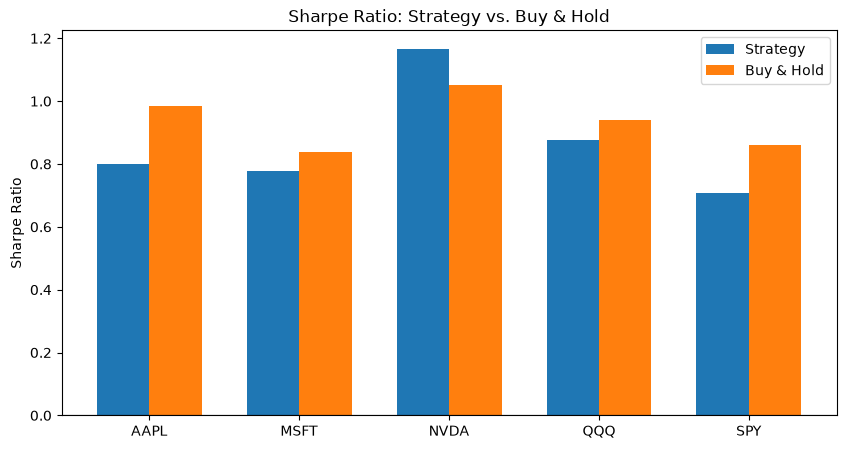

In [3]:
tickers = sorted(bt["Ticker"].unique())
strategy_sharpe = [summary.loc[(t, "Strategy"), "SharpeRatio"] for t in tickers]
benchmark_sharpe = [summary.loc[(t, "Benchmark"), "SharpeRatio"] for t in tickers]

x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, strategy_sharpe, width, label="Strategy")
ax.bar(x + width / 2, benchmark_sharpe, width, label="Buy & Hold")
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Sharpe Ratio: Strategy vs. Buy & Hold")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.show()


## CAGR and volatility: strategy vs. benchmark


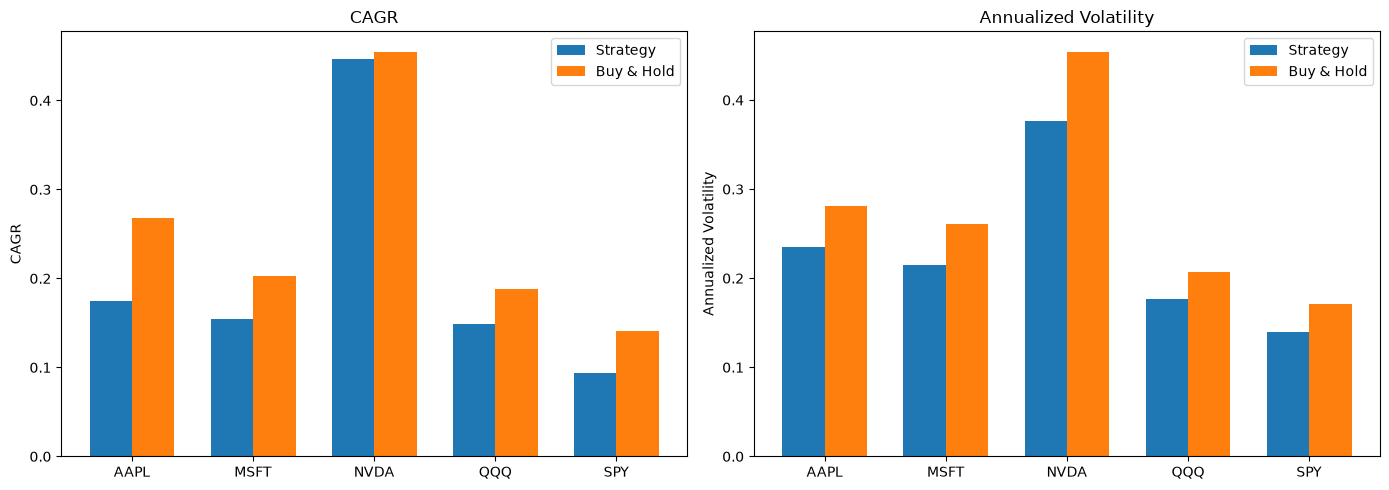

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strategy_cagr = [summary.loc[(t, "Strategy"), "CAGR"] for t in tickers]
benchmark_cagr = [summary.loc[(t, "Benchmark"), "CAGR"] for t in tickers]
axes[0].bar(x - width / 2, strategy_cagr, width, label="Strategy")
axes[0].bar(x + width / 2, benchmark_cagr, width, label="Buy & Hold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tickers)
axes[0].set_ylabel("CAGR")
axes[0].set_title("CAGR")
axes[0].legend()

strategy_vol = [summary.loc[(t, "Strategy"), "AnnualizedVolatility"] for t in tickers]
benchmark_vol = [summary.loc[(t, "Benchmark"), "AnnualizedVolatility"] for t in tickers]
axes[1].bar(x - width / 2, strategy_vol, width, label="Strategy")
axes[1].bar(x + width / 2, benchmark_vol, width, label="Buy & Hold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers)
axes[1].set_ylabel("Annualized Volatility")
axes[1].set_title("Annualized Volatility")
axes[1].legend()

plt.tight_layout()
plt.show()


## Results

Over this 2010-2026 sample, buy-and-hold beats the 50/200-day moving-average strategy on **both raw return and Sharpe ratio** for four of the five tickers (AAPL, MSFT, QQQ, SPY). The strategy only wins on a risk-adjusted basis for **NVDA**, where its volatility reduction (37.6% vs. 45.4% annualized) is large enough to offset giving up some return, producing a higher Sharpe ratio (1.17 vs. 1.05) despite lower CAGR (44.6% vs. 45.5%).

So, for this universe and time period: **no, the strategy does not generally outperform buy-and-hold on a risk-adjusted basis** -- the exception (NVDA) is plausible (trend-following tends to help most on the most volatile assets, where avoiding sustained drawdowns matters most) but is a single data point, not a robust pattern established here.

This lines up with well-documented research on trend-following: it tends to underperform simple buy-and-hold during long, uninterrupted bull markets, and its case is usually made instead on avoiding the worst *sustained* drawdowns (e.g. 2000-2002, 2007-2009) rather than on beating a rising market outright.


## Limitations

- **0% risk-free rate assumption.** Real Sharpe ratios would be somewhat lower, especially in higher-rate periods; the *relative* ranking between strategy and benchmark would likely still hold, but the absolute numbers shouldn't be taken literally.
- **No transaction costs or slippage.** Every trade is assumed free and executed exactly at the close. With ~13-21 trades per ticker over 16 years this is a small strategy-level effect, but not zero.
- **A single, untuned parameter choice (50/200 days).** We didn't test whether these specific windows are special, or how sensitive results are to nearby choices (e.g. 40/180, 60/220) -- that's parameter sensitivity testing, not done here.
- **No statistical significance testing.** We haven't asked whether these Sharpe-ratio differences are distinguishable from noise, given how few independent bull/bear cycles are in a 16-year sample.
- **Small, survivorship-biased universe.** All five tickers are large, currently-thriving companies/funds precisely because they survived and did well -- a real backtest over a broader, point-in-time-correct universe would likely show different, probably weaker, results for both strategy and benchmark.
- **Single, bull-market-dominated sample period.** 2010-2026 had no sustained multi-year bear market -- the scenario trend-following is specifically meant to help with. Out-of-sample and walk-forward testing across different regimes is needed before drawing broader conclusions.


## Next Steps

This completes the initial Project 1 pipeline: data -> returns -> signals -> backtest -> performance analysis. Planned extensions:

**Phase 2:** transaction costs, alternate MA parameters, a broader set of stocks, out-of-sample testing, walk-forward testing.

**Phase 3:** volatility targeting, position sizing, momentum factors, regime analysis, statistical significance testing.
